# Fraudulent Transactions — Modeling

## Methodology: CRISP-DM

This notebook covers phases 5 through 9. Phases 1 to 4 are in `01_eda.ipynb`.

5. Data cleaning and preprocessing
6. Model training, comparison, selection and tuning
7. Final production model testing and evaluation
8. Conclude and interpret the model results
9. Deploy

All logic lives in the `fraud_detection` package. This notebook is the narrative and
the call sequence; nothing is defined here.

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt

from fraud_detection import config as cfg
from fraud_detection import preprocessing as prep
from fraud_detection import model as mdl
from fraud_detection import reporting as rpt
from fraud_detection import deployment as dep

/data/PROJETOS/ALURA-FRAUDE/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# **5. DATA AND PARTITIONS**

In [2]:
df = prep.load_transactions()

splits = prep.chronological_split(df)
summary = prep.describe_splits(splits)
summary

,step_from,step_to,day_from,day_to,rows,frauds,fraud_rate
partition,,,,,,,
TRAIN,1,301,1,13,4104531,3405,0.000830
VAL,302,355,13,15,1009353,558,0.000553
TEST,356,743,15,31,1248736,4250,0.003403


In [3]:
rpt.show(rpt.split_insights(summary))

##### 1. Why the Split Is Chronological
* `step` maps 743 consecutive hours of simulation, so the dataset is a time
  series wearing a tabular disguise. A random split would place future
  transactions in training and past transactions in testing.
* PaySim implements each fraud as two linked rows — a TRANSFER out of the
  compromised account, then a CASH_OUT of the same amount. A random split
  separates those twins across partitions, leaving the model only to match an
  amount it has already seen. `stratify` does not prevent this: it balances the
  label, not the entity.
* **Modeling Decision:** Train on steps 1–301 (days 1 to 13), select the
  threshold on steps 302–355 (days 13 to 15), and test on steps 356–743
  (days 15 to 31). The test partition is read exactly once, after every
  modeling decision is locked.

##### 2. Prevalence Drifts Sharply Between Partitions
* Volume is front-loaded, so the 80% quantile of `step` weighted by row count
  lands at step 301, day 13 — not near day 25 as a naive reading of
  0.8 × 743 would suggest.
* Fraud prevalence is **0.0830%** in TRAIN, **0.0553%** in VAL and **0.3403%** in
  TEST. The test period is **4.1x more hostile** than the period the model learns from.
* TEST holds 4,250 of the 8,213 frauds in the dataset — **51.7% of all fraud
  in 19.6% of the rows**. The chronological cut did not merely reorder the
  data, it concentrated the positive class in the held-out period.
* **Modeling Decision:** Report prevalence per partition alongside every metric.
  PR-AUC is a function of base rate, so a test score is not comparable to a
  validation score without both. A drop from validation to test is expected here
  and is not by itself evidence of overfitting.

#### **Preprocessing contract**

`prep.build_pipeline` returns preprocessing, optional resampling and the estimator as a
single object. Resampling is a pipeline *step*, so it is re-fitted on every training fold
and never sees the validation fold — applying SMOTE to a dataset in advance is the leak
that signature exists to prevent. Note that `sklearn.pipeline.Pipeline` rejects
resamplers, hence imblearn's variant.

Two feature sets are declared in `config`. `REALTIME_FEATURES` holds only what exists at
authorisation time. `FORENSIC_FEATURES` adds four post-settlement balances which, in
PaySim, encode the label almost tautologically — valid for a post-settlement review
queue, never for real-time scoring. The gap between the two is the measured cost of that
leakage.

# **6. MODEL TRAINING, COMPARISON, SELECTION AND TUNING**

In [4]:
search = prep.stratified_search_sample(splits.train)
print(f"Search sample: {search.height:,} rows | "
      f"{search[cfg.TARGET].sum():,} frauds ({search[cfg.TARGET].mean():.4%})")

Search sample: 615,680 rows | 511 frauds (0.0830%)


Logistic Regression    PR-AUC 0.6404 (+/- 0.0434)  [9.3s]
Decision Tree          PR-AUC 0.6697 (+/- 0.2649)  [8.3s]
Random Forest          PR-AUC 0.9884 (+/- 0.0102)  [89.8s]
XGBoost                PR-AUC 0.9693 (+/- 0.0233)  [8.9s]


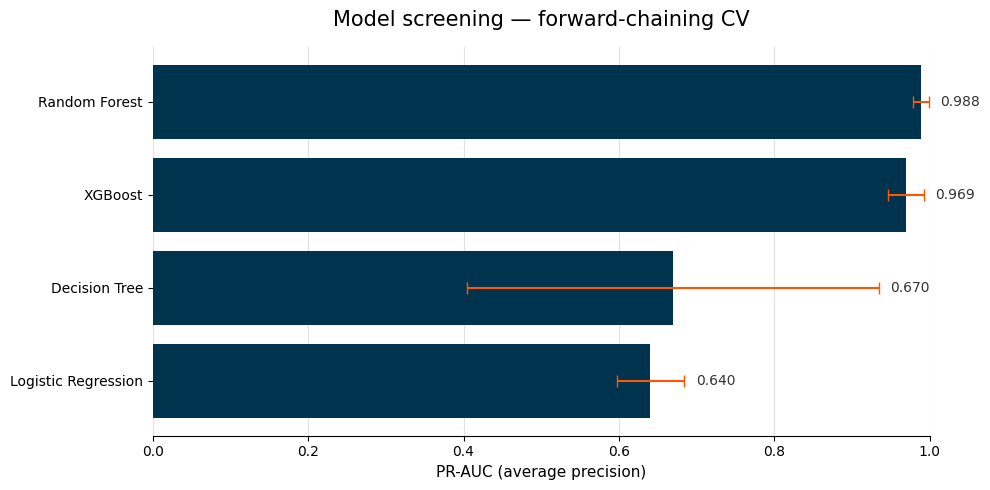

,PR-AUC (CV),Std,Fit time (s)
Logistic Regression,0.640402,0.043432,9.349866
Decision Tree,0.669665,0.264867,8.327028
Random Forest,0.988440,0.010207,89.754662
XGBoost,0.969267,0.023335,8.933558


In [5]:
df_results = mdl.screen_models(search, cfg.FORENSIC_FEATURES)
rpt.plot_screening(df_results)
plt.show()
df_results

In [6]:
rpt.show(rpt.screening_insights(df_results, search))

* **A Leak-Free Baseline Produces Spread:** PR-AUC ranges from **0.6404**
  (Logistic Regression) to **0.9884** (Random Forest). The spread is itself evidence that the
  evaluation works — near-identical perfect scores across algorithms of very
  different capacity is the signature of a leaked target, not of an easy problem.
* **The Top Two Are a Statistical Tie:** Random Forest leads at **0.9884 ± 0.0102** against XGBoost at **0.9693 ± 0.0233**. The 0.0192 gap sits inside XGBoost's own standard deviation, so this is not a ranking.
* **Fold Variance Is Load-Bearing:** the search sample holds 511 frauds across
  615,680 rows, split into 4 chronological blocks of roughly 153,920 rows —
  about 127 frauds each. No ranking at that resolution should be treated as
  decisive, and models with a standard deviation above 0.10 are memorising
  whichever fraud burst happens to sit in their training window.
* **Modeling Decision:** Carry **XGBoost** into the tuning stage. It fits in
  **8.9s against 89.8s** — 10x faster — and runtime is a
  selection criterion, not a footnote: the tuning stage multiplies it by trials
  times folds.

In [7]:
studies = mdl.tune(search)


--- tuning: forensic (11 features) ---
  trial   0 | PR-AUC 0.9595 | best 0.9595
  trial   1 | PR-AUC 0.9888 | best 0.9888
  trial   5 | PR-AUC 0.9806 | best 0.9888
  trial   8 | PR-AUC 0.9889 | best 0.9889
  trial  10 | PR-AUC 0.9884 | best 0.9889
  trial  12 | PR-AUC 0.9898 | best 0.9898
  trial  13 | PR-AUC 0.9900 | best 0.9900
  trial  15 | PR-AUC 0.9900 | best 0.9900
  trial  17 | PR-AUC 0.9907 | best 0.9907
  trial  20 | PR-AUC 0.9860 | best 0.9907
  best CV PR-AUC: 0.9907 | balance: scale_pos_weight

--- tuning: realtime (7 features) ---
  trial   0 | PR-AUC 0.5940 | best 0.5940
  trial   1 | PR-AUC 0.6564 | best 0.6564
  trial   2 | PR-AUC 0.6865 | best 0.6865
  trial   5 | PR-AUC 0.5929 | best 0.6865
  trial  10 | PR-AUC 0.6573 | best 0.6865
  trial  15 | PR-AUC 0.6550 | best 0.6865
  trial  20 | PR-AUC 0.6820 | best 0.6865
  trial  24 | PR-AUC 0.6893 | best 0.6893
  best CV PR-AUC: 0.6893 | balance: scale_pos_weight



forensic — parameter importance
  balance              0.4877
  gamma                0.1413
  learning_rate        0.1220
  reg_lambda           0.0780
  subsample            0.0406
  max_depth            0.0402
  n_estimators         0.0364
  colsample_bytree     0.0306
  min_child_weight     0.0202
  reg_alpha            0.0030

realtime — parameter importance
  balance              0.5704
  learning_rate        0.2147
  reg_lambda           0.0634
  colsample_bytree     0.0449
  max_depth            0.0416
  reg_alpha            0.0270
  gamma                0.0203
  min_child_weight     0.0095
  n_estimators         0.0053
  subsample            0.0029


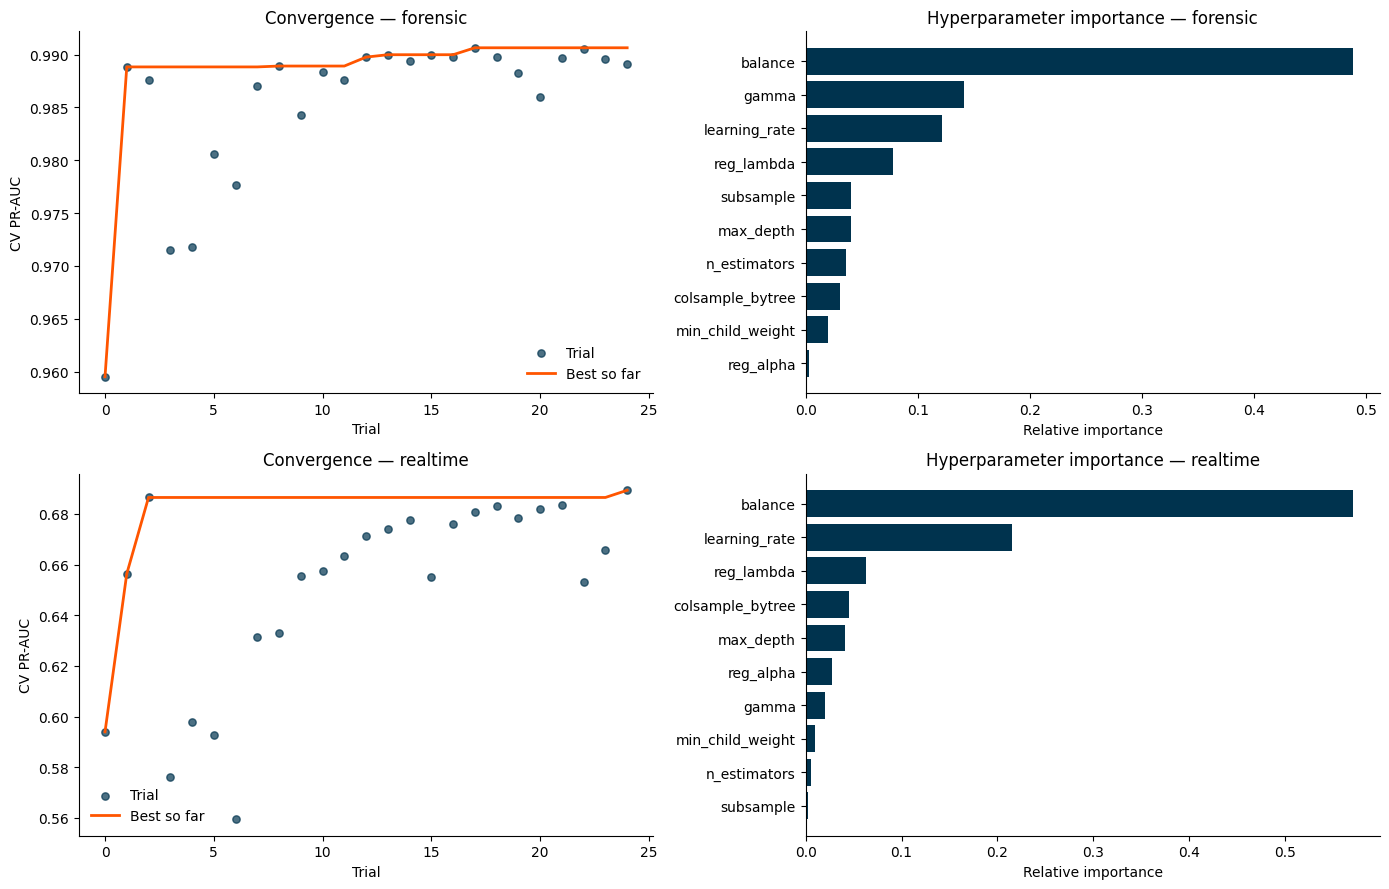

In [8]:
rpt.plot_tuning(studies)
plt.show()

In [9]:
rpt.show(rpt.tuning_insights(studies, df_results, search))

##### 1. Class Balancing Treated as a Hyperparameter
* Rather than assuming SMOTE, the search chooses between synthetic oversampling
  and `scale_pos_weight`, letting the objective settle the question empirically.
* On the **forensic** feature set it converged on **`scale_pos_weight`** at a weight of **35.5** — **3%** of the natural imbalance ratio of 1,203.9.
* On the **realtime** feature set it converged on **`scale_pos_weight`** at a weight of **439.1** — **36%** of the natural imbalance ratio of 1,203.9.
* Every set lands **below** the natural ratio, so full inverse-frequency weighting overshoots on this data — a modeling finding, not a default.
* On a 615,680-row search sample, SMOTE's nearest-neighbour step also
  dominates fit time, while gradient boosting absorbs the imbalance through the loss.
* **Modeling Decision:** Record the chosen strategy explicitly. A reviewer will
  otherwise assume it was left at its default.

##### 2. What the Search Actually Bought
* **forensic**: best CV PR-AUC **0.9907**, at trial **17 of 25**, 6.9 min total.
* **realtime**: best CV PR-AUC **0.6893**, at trial **24 of 25**, 7.4 min total — the best trial was the last one, so the search had not yet plateaued.
* Against the untuned XGBoost screening baseline of **0.9693** (same
  forensic feature set), tuning moved the objective by **+0.0214**.
* The other feature set has no screening counterpart — the comparison in section 6
  ran on the forensic matrix — so its score is reported on its own
  terms rather than as a delta.
* **Modeling Decision:** An early plateau means hyperparameters are no longer the
  binding constraint. Further effort belongs in feature engineering — per-account
  velocity counters over a trailing `step` window, the one signal class this matrix
  lacks entirely — rather than in a wider or longer search.

# **7. FINAL PRODUCTION MODEL TESTING AND EVALUATION**

In [10]:
results = mdl.evaluate_feature_sets(splits, studies)
mdl.summarize(results)


forensic  |  threshold = 0.8869
PR-AUC 0.9995 | ROC-AUC 1.0000
              precision    recall  f1-score   support

       Legit     1.0000    1.0000    1.0000   1244486
       Fraud     0.9945    0.9871    0.9908      4250

    accuracy                         0.9999   1248736
   macro avg     0.9973    0.9935    0.9954   1248736
weighted avg     0.9999    0.9999    0.9999   1248736

TP 4,195 | FP 23 | FN 55 | TN 1,244,463

realtime  |  threshold = 0.9544
PR-AUC 0.9009 | ROC-AUC 0.9990
              precision    recall  f1-score   support

       Legit     0.9993    0.9997    0.9995   1244486
       Fraud     0.9115    0.7805    0.8409      4250

    accuracy                         0.9990   1248736
   macro avg     0.9554    0.8901    0.9202   1248736
weighted avg     0.9990    0.9990    0.9990   1248736

TP 3,317 | FP 322 | FN 933 | TN 1,244,164


,forensic,realtime
threshold,8.868932e-01,9.544314e-01
PR-AUC,9.994822e-01,9.008545e-01
ROC-AUC,9.999922e-01,9.990047e-01
precision,9.945472e-01,9.115142e-01
recall,9.870588e-01,7.804706e-01
flag rate,3.377816e-03,2.914147e-03
TP,4.195000e+03,3.317000e+03
FP,2.300000e+01,3.220000e+02
FN,5.500000e+01,9.330000e+02
TN,1.244463e+06,1.244164e+06


In [11]:
rpt.show(rpt.evaluation_insights(results))

##### 1. The Measured Cost of Leakage
* The forensic feature set reaches **0.9995** PR-AUC on the held-out period; the
  realtime set reaches **0.9009**. The gap of **+0.0986** is attributable to
  4 columns that do not exist at the moment an authorisation decision must
  be made.
* **Modeling Decision:** The realtime figure belongs in the project summary. The
  forensic figure describes a different product — a post-settlement review queue —
  and is labelled as such wherever it appears.

##### 2. Precision, Recall, and the Cost Asymmetry
* At the validation-selected threshold of **0.9544**, the deployable model catches
  **78.05%** of frauds at **91.15%** precision: 3,317 true positives against 322
  false positives and 933 missed frauds, over 1,248,736 test transactions.
* It sends **0.291%** of all traffic for review. For every 1,000 flags, roughly
  912 are genuine fraud.
* Section 1 defined success as a high detection rate while strictly controlling false
  positives. Those objectives trade continuously along the PR curve, and the threshold
  is where the trade is priced.
* The threshold maximises F1 on validation, which assumes a false positive and a missed
  fraud cost the same. They do not.
* **Modeling Decision:** Re-derive the operating point with
  `model.threshold_for_cost_ratio` once the business supplies a ratio. The model does
  not change; only the cut does.

##### 3. Benchmark Against the Incumbent Rule
* The existing engine flags transfers above 200,000, firing on 0.000003 of
  transactions against a true fraud rate of 0.001291 — an upper bound of
  **0.23%** on the share of frauds it could possibly catch.
* The deployable model detects **78.05%**, roughly **336x** that ceiling.
* **Modeling Decision:** Frame the business case against the current rule, not against
  zero. The question is whether the model beats what is already running, by a margin
  that justifies the false positives it introduces.

# **8. CONCLUDE AND INTERPRET THE MODEL RESULTS**

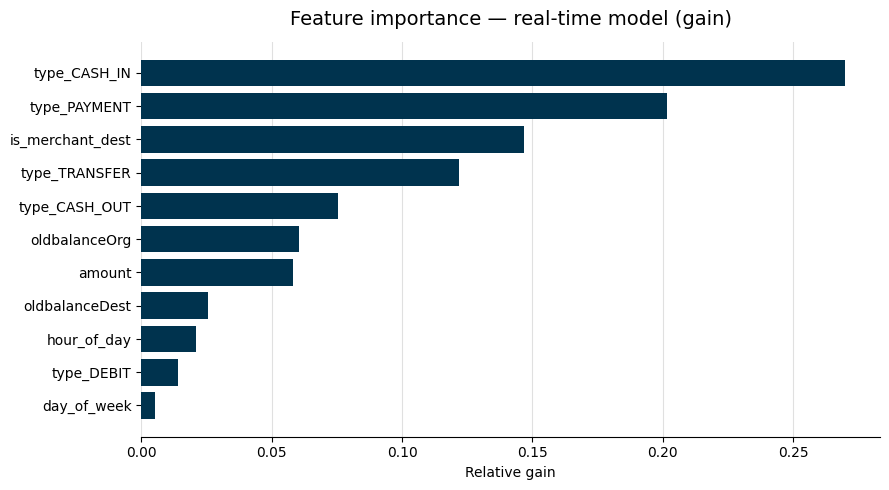

,gain
type_CASH_IN,0.269886
type_PAYMENT,0.201820
is_merchant_dest,0.146606
type_TRANSFER,0.121988
type_CASH_OUT,0.075479
oldbalanceOrg,0.060284
amount,0.058186
oldbalanceDest,0.025392
hour_of_day,0.021103
type_DEBIT,0.014141


In [12]:
deployable = results['realtime']

importance = mdl.gain_importance(deployable.pipeline)
rpt.plot_importance(importance, title='Feature importance — real-time model (gain)')
plt.show()
importance.to_frame('gain')

In [13]:
mdl.permutation_table(deployable.pipeline, splits.val, cfg.REALTIME_FEATURES)

,mean PR-AUC drop,std
oldbalanceOrg,0.787361,0.011036
amount,0.777118,0.005879
type,0.515839,0.028213
oldbalanceDest,0.298633,0.023080
hour_of_day,0.156126,0.012419
is_merchant_dest,0.024757,0.010614
day_of_week,-0.005215,0.002735


In [14]:
rpt.show(rpt.conclusion_insights(results, importance))

##### 1. What the Model Learned
* Gain concentrates in `type_CASH_IN` (27.0%) and `type_PAYMENT` (20.2%),
  confirming Section 4's finding that transaction type alone separates safe channels
  from risky ones — PAYMENT, CASH_IN and DEBIT contain zero recorded frauds, so the
  model spends no capacity on them.
* `hour_of_day` contributes 2.1%, consistent with the observation that fraudulent
  volume stays flat overnight while legitimate volume collapses. The model is not
  learning that 4:00 AM is dangerous; it is learning that 4:00 AM is *empty*, and that
  anything moving through an empty network deserves scrutiny.
* 1 of 11 encoded features carry under 1% of gain each. Read this beside the
  permutation table: gain rewards features used often in splits, permutation rewards
  features the metric actually depends on, and where the two disagree the permutation
  result is the one tied to PR-AUC.

##### 2. Performance Against the Incumbent
* The deployable model achieves **78.05%** recall at **91.15%** precision on a test
  period it never saw, roughly **336x** the incumbent rule's ceiling of
  0.23%.
* **Business Reading:** For every 1,000 transactions flagged, approximately
  912 are genuine frauds, and 933 frauds still pass unflagged. Whether that
  trade is acceptable is a business decision, not a modeling one, and it moves
  continuously along the threshold.

##### 3. Honest Limitations
* **Synthetic data.** PaySim is a simulator. Its fraud agents follow programmed rules, which are learnable in a way real adversaries are not. Every number here is an upper bound on real-world performance.
* **No adversarial drift.** The model is validated on one month of a static simulation. Real fraud patterns shift in response to detection, so production performance decays without retraining.
* **Single-transaction scope.** The model scores each transaction in isolation. It cannot see that an account received three transfers in the previous ten minutes, which is how fraud rings actually appear.
* **Threshold assumes symmetric costs.** F1 optimisation treats a blocked legitimate customer and a missed fraud as equally bad. They are not.
* **Train and test are not exchangeable.** Fraud prevalence is several times higher in the test period than in training, so the reported score describes a more hostile regime than the model learned from. Realistic, but not a stationary estimate.

##### 4. Recommended Next Steps
* Engineer per-account velocity aggregates over a trailing window of `step`, computed strictly from past rows to preserve causal ordering.
* Re-derive the threshold with `mdl.threshold_for_cost_ratio` once the business supplies a false-negative to false-positive cost ratio.
* Establish a monitoring baseline on prediction distribution and flag rate, so drift is detected before recall degrades silently.
* Validate against real transactional data before any production consideration.

# **9. DEPLOY**

In [15]:
artifact_path = dep.save_artifact(deployable, splits, studies['realtime'])

{
  "threshold": 0.9544313549995422,
  "features": [
    "type",
    "amount",
    "oldbalanceOrg",
    "oldbalanceDest",
    "is_merchant_dest",
    "hour_of_day",
    "day_of_week"
  ],
  "categorical": [
    "type"
  ],
  "excluded_post_settlement": [
    "newbalanceOrig",
    "newbalanceDest",
    "errorBalanceOrig",
    "errorBalanceDest"
  ],
  "test_pr_auc": 0.9008545422873111,
  "test_recall": 0.7804705882352941,
  "test_precision": 0.9115141522396263,
  "train_steps": [
    1,
    301
  ],
  "test_steps": [
    356,
    743
  ],
  "best_params": {
    "n_estimators": 400,
    "max_depth": 9,
    "learning_rate": 0.014077834486909541,
    "subsample": 0.60362662491687,
    "colsample_bytree": 0.768237566103353,
    "min_child_weight": 20,
    "gamma": 1.276574514764971,
    "reg_lambda": 0.006541090634629908,
    "reg_alpha": 0.7061956737193918,
    "balance": "scale_pos_weight",
    "scale_pos_weight": 439.13318059733933
  },
  "trained_at": "2026-07-27T02:48:18.368380+00:00",

In [16]:
preview = dep.score_transactions(splits.test.head(10_000), dep.load_artifact(artifact_path))
print(f"Flagged: {preview['flagged'].sum()} of {preview.height}")
preview.select(['step', 'type', 'amount', 'isFraud', 'fraud_probability', 'flagged']).head()

Flagged: 0 of 10000


step,type,amount,isFraud,fraud_probability,flagged
i64,str,f64,i64,f32,i64
356,"""CASH_IN""",162108.65,0,0.00118,0
356,"""PAYMENT""",9968.76,0,0.001002,0
356,"""PAYMENT""",30562.71,0,0.000998,0
356,"""CASH_OUT""",75714.16,0,0.003892,0
356,"""PAYMENT""",13416.67,0,0.001083,0


#### **Scoring contract**

`dep.score_transactions(frame, artifact)` requires every column in
`artifact['features']`. Three are derived rather than raw — `is_merchant_dest`,
`hour_of_day`, `day_of_week` — and are the caller's responsibility; all three depend only
on fields available at authorisation time.

Post-settlement columns are **rejected, not ignored**. A caller supplying them is
describing a transaction that has already completed, at which point prevention is no
longer possible, and silently accepting them is how a forensic model ends up deployed as
a real-time one.

The threshold ships inside the artifact deliberately. A model saved without its operating
point is not usable: whoever loads it will call `predict` at 0.5 and get a recall
unrelated to the one reported above.